<a href="https://colab.research.google.com/github/Areca293/Evaluating-the-Isolation-Forest-unsupervised-anomaly-detector-of-onEEGWaveLAD/blob/main/onEEGwaveLAD_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# Setup & Imports
# ==========================================
!pip install mne isotree

import pathlib as pl
import numpy as np
import mne
import pywt
import pandas as pd
from isotree import IsolationForest
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

print("Libraries imported and Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported and Google Drive mounted successfully.


In [2]:
# ==========================================
# Dataset Loading
# ==========================================
import pathlib as pl
import mne

def loadDataset(name, subject, montageName, usedChannels, rootPath, montageChannelNames, parametersOfDenoiser=None, verbose=False):
    """
    Loads the EEG dataset according to the pre-defined folder structure.
    Extracts the shifted data version for temporal alignment.
    """
    dataset = pl.Path(name)
    subject = str(subject)
    root = pl.Path(rootPath)

    # Construct the file pathway for raw EEG data files
    pathDataset = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/")
    filenameSubject = pl.Path(subject + "_" + dataset.name + "_" + "shifted.set")
    pathDatasetSubject = pl.Path.joinpath(pathDataset, subject, filenameSubject)

    # Construct the file pathway for the EEG sensor coordinate (Montage) file
    filenameMontage = pl.Path(str("standard-10-5-cap385.elp"))
    montagePath = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/", "EEG_ERP_Processing", filenameMontage)

    # Ingest EEGLAB format files using the MNE framework
    dataForSubject = mne.io.read_raw_eeglab(pathDatasetSubject, preload=True)
    dataForSubject.rename_channels(lambda s: s.strip("."))

    channels = dataForSubject.info["ch_names"]
    sampleFreq = dataForSubject.info["sfreq"]

    if verbose:
        print("Data summary before pre-processing: {}".format(dataForSubject))
        print("Metadata structure before pre-processing: {}".format(dataForSubject.info))

        print("Loading file: " + str(filenameSubject))
        print("Root path: ", root)
        print("Dataset directory: ", pathDataset)
        print("Subject path location: ", pathDatasetSubject)
        print("Montage file path: ", montagePath)
        print("Data successfully loaded for subject: {}".format(subject))
        print("Identified channels: {}".format(channels))

        # Output experimental event markings and stimulus annotations
        print("Annotations data: " + str(dataForSubject.annotations))
        print("Annotation durations shape: " + str(dataForSubject.annotations.duration.shape))
        print("Annotation descriptions shape: " + str(dataForSubject.annotations.description.shape))
        print("Annotation onsets shape: " + str(dataForSubject.annotations.onset.shape))
        if len(dataForSubject.annotations.onset) > 0:
            print("Initial event timestamp: " + str(dataForSubject.annotations.onset[0]))
        print(list(dataForSubject.annotations.description))

        # Render raw EEG signal configurations
        dataForSubject.plot()

    return dataForSubject

In [3]:
# ==========================================
# Step A: EEG Windowing Configuration
# ==========================================
class OnEEGWaveLAD_Windowing:
    def __init__(self, raw_data, RTWL=1000):
        self.raw = raw_data
        self.Sr = raw_data.info['sfreq'] # Sampling frequency (Hz)
        self.RTWL = RTWL                 # Target Real-Time Window Length (ms)

        # Compute the theoretical sample points for the designated window duration
        theoretical_samples = (self.RTWL / 1000.0) * self.Sr

        # Adjust the sample count to the nearest upper power of 2 to optimize wavelet operations
        self.window_samples = int(2 ** np.ceil(np.log2(theoretical_samples)))

        # Derive the actual processing window length in milliseconds
        self.actual_RTWL = (self.window_samples / self.Sr) * 1000.0

        print(f"[Phase A] Target processing window length: {self.RTWL} ms")
        print(f"[Phase A] Adjusted operational window length: {self.actual_RTWL:.2f} ms ({self.window_samples} samples).")

        self.total_samples = raw_data.n_times

    def get_window_stream(self):
        """
        Sequentially partitions the continuous EEG signal into discrete windows.
        Yields segments as a localized data structure simulating real-time streaming blocks.
        """
        for start_idx in range(0, self.total_samples, self.window_samples):
            end_idx = start_idx + self.window_samples
            if end_idx > self.total_samples:
                break

            curr_window, _ = self.raw[:, start_idx:end_idx]

            yield {
                "start_idx": start_idx,
                "end_idx": end_idx,
                "original_window": curr_window,
                "dwt_input": curr_window
            }

## Step B: Multi-level Decomposition
Applies the Pyramidal Sub-band Coding scheme using the Discrete Wavelet Transform (DWT). The EEG window is decomposed into its constituent frequency sub-bands (approximation and detail coefficients) using a specified Mother Wavelet (`MW`).

In [4]:
# ==========================================
# Step B: Multi-level Discrete Wavelet Decomposition
# ==========================================
class OnEEGWaveLAD_DWT:
    def __init__(self, MW='sym4', decomposition_level=None):
        self.MW = MW
        self.level = decomposition_level

    def decompose_window(self, dwt_input_data):
        signal_length = dwt_input_data.shape[1]

        if self.level is None:
            # Determine the maximum mathematically valid decomposition level for the selected mother wavelet
            max_level = pywt.dwt_max_level(signal_length, self.MW)
            # Select the optimal decomposition level constrained by the signal boundary conditions
            actual_level = min(int(np.log2(signal_length)), max_level)
        else:
            actual_level = self.level

        return [pywt.wavedec(dwt_input_data[ch], self.MW, level=actual_level, mode='periodization')
                for ch in range(dwt_input_data.shape[0])]

In [5]:
# =================================================================
# Phases C - G: Multi-scale Anomaly Detection and Signal Reconstruction
# =================================================================
from isotree import IsolationForest
import numpy as np
import pywt

class OnEEGWaveLAD_Denoiser:
    """
    Core Unsupervised Denoising Framework.
    Implements scaleogram formation, anomaly detection via Extended Isolation Forest,
    and adaptive artifact attenuation.
    """
    def __init__(self, n_channels, Bs=20, IFt=100, IFS=512, Ta=0.55, Es=35, el=None):
        # Hyperparameters strictly correspond to the mathematical model established in the thesis:
        # Bs : Buffer Size
        # IFt: Number of trees in Extended Isolation Forest
        # IFS: Isolation Forest Sample Size
        # Ta : Anomaly Score Threshold
        # Es : Expansion Size for structural artifact attenuation
        self.n_channels = n_channels
        self.Bs = Bs
        self.IFt = IFt
        self.IFS = IFS
        self.Ta = Ta
        self.Es = Es
        self.el = el

        # Maintain channel-specific adaptive moving buffers to track temporal baseline history
        self.moving_buffers_history = [[] for _ in range(n_channels)]
        self.models = [None for _ in range(n_channels)]
        self.centroids = [None] * n_channels
        self.max_dists = [None] * n_channels

    def process_window(self, all_channels_coeffs, target_len, MW='sym4', return_debug=False, debug_channel=0):
        denoised_signals = []
        debug_info = {}

        # Number of Instantaneous Spectral Profiles (ISPs) represents the temporal
        # resolution of the scaleogram, derived from half the target length.
        n_isps = target_len // 2

        for ch in range(self.n_channels):
            coeffs = all_channels_coeffs[ch]

            # Separate baseline approximation coefficients (cA) from detail coefficients (cD)
            cA_baseline = coeffs[0]
            details = coeffs[1:]
            num_scales = len(details)

            # [Phase C] Scaleogram Formation: Reshaper & Normalizator
            # Constructs a 2D scaleogram representation from 1D wavelet detail coefficients.
            raw_scaleogram = np.zeros((n_isps, num_scales))
            norm_scaleogram = np.zeros((n_isps, num_scales))

            for i, c in enumerate(details):
                m_level = num_scales - i
                repeats = n_isps // len(c)
                upsampled = np.repeat(c, repeats)

                raw_scaleogram[:, i] = upsampled
                norm_scaleogram[:, i] = upsampled / (2 ** m_level)

            if return_debug and ch == debug_channel:
                debug_info['Step_C_Scaleogram_Raw'] = raw_scaleogram.copy()
                debug_info['Step_C_Scaleogram_Before'] = norm_scaleogram.copy()

            # [Phase E] Artifact Identification: Outlier Scoring via Extended Isolation Forest
            # Evaluates the anomaly score for each ISP in the current analytical window.
            if self.models[ch] is not None:
                scores = self.models[ch].predict(norm_scaleogram)
            else:
                scores = np.zeros(n_isps)

            if return_debug and ch == debug_channel:
                debug_info['Step_E_Scores'] = scores.copy()

            # [Phase D] Channel-Specific Adaptive Moving Buffer Management
            # Updates the historical buffer with the current normalized scaleogram to dynamically
            # adapt to non-stationary shifts in the continuous EEG signal.
            self.moving_buffers_history[ch].append(norm_scaleogram)
            if len(self.moving_buffers_history[ch]) > self.Bs:
                self.moving_buffers_history[ch].pop(0)

            moving_buffer = np.vstack(self.moving_buffers_history[ch])

            if return_debug and ch == debug_channel:
                debug_info['Step_D_Moving_Buffer'] = moving_buffer.copy()

            # Calculate mathematical centroids to measure relative structural deviations
            self.centroids[ch] = np.mean(moving_buffer, axis=0)
            self.max_dists[ch] = np.max(np.abs(moving_buffer - self.centroids[ch]), axis=0) + 1e-8

            # Fit the unsupervised anomaly detection model once the buffer reaches critical capacity
            if moving_buffer.shape[0] >= self.IFS:
                c_dim = moving_buffer.shape[1]
                actual_ndim = c_dim if self.el is None else min(self.el + 1, c_dim)
                self.models[ch] = IsolationForest(ntrees=self.IFt, sample_size=self.IFS, ndim=actual_ndim, random_seed=42)
                self.models[ch].fit(moving_buffer)

            # [Phase F] Artifact Reduction Mitigator via Scale-Specific Attenuation
            # Applies a continuous soft-thresholding mask to attenuate identified anomalous ISPs.
            AT_exp = {idx + e for idx in np.where(scores > self.Ta)[0]
                      for e in range(-self.Es, self.Es + 1) if 0 <= idx + e < n_isps}

            mitigator = np.ones((n_isps, num_scales))

            for idx in AT_exp:
                dist_vec = np.abs(norm_scaleogram[idx] - self.centroids[ch])
                mtga_vec = 1.0 - (dist_vec / self.max_dists[ch])
                mtga_vec = np.clip(mtga_vec, 0.0, 1.0)
                mitigator[idx] = np.minimum(mitigator[idx], mtga_vec)

            if return_debug and ch == debug_channel:
                debug_info['Step_F_Mitigator'] = mitigator.copy()

            # Element-wise multiplication to yield the denoised wavelet structure
            denoised_scaleogram = raw_scaleogram * mitigator

            if return_debug and ch == debug_channel:
                mod_norm_scaleogram = np.zeros_like(denoised_scaleogram)
                for i in range(num_scales):
                    m_level = num_scales - i
                    mod_norm_scaleogram[:, i] = denoised_scaleogram[:, i] / (2 ** m_level)
                debug_info['Step_C_Scaleogram_After'] = mod_norm_scaleogram.copy()

            # [Phase G] Multi-level Composition: Expansor, Reshaper, and iDWT
            # Reconstructs the clean time-domain EEG signal from the processed scaleogram.
            reconstructed_coeffs = [cA_baseline.copy()]

            for i in range(num_scales):
                repeats = n_isps // len(details[i])
                # Expansor module: Restores the attenuated structural row to its original temporal dimension
                expanded_row = denoised_scaleogram[:, i]
                # Reshaper module: Reverses the upsampling process to retrieve the valid discrete detail coefficients
                reshaped_coeffs = expanded_row[::repeats]
                reconstructed_coeffs.append(reshaped_coeffs)

            # Apply Inverse Discrete Wavelet Transform (iDWT) to generate the final denoised block
            denoised_sig = pywt.waverec(reconstructed_coeffs, MW, mode='periodization')
            denoised_signals.append(denoised_sig[:target_len])

        if return_debug:
            return np.array(denoised_signals), debug_info
        return np.array(denoised_signals)

In [6]:
# ==========================================
# Batch Evaluator
# ==========================================
class OnEEGWaveLAD_BatchEvaluator:
    def __init__(self, original, denoised, window_size):
        self.orig = original
        self.denoised = denoised
        self.w_size = window_size
        self.num_windows = self.orig.shape[1] // self.w_size

    def get_metrics(self, channel_idx, thresh=90):
        """
        Computes JSD and SNR parameters for classified target segments (artifacts vs clean).
        """
        orig_ch = self.orig[channel_idx] * 1e6
        denoised_ch = self.denoised[channel_idx] * 1e6
        jsd_tps, jsd_tns, snr_tps, snr_tns = [], [], [], []

        for i in range(self.num_windows):
            start, end = i * self.w_size, (i + 1) * self.w_size
            w_o, w_d = orig_ch[start:end], denoised_ch[start:end]

            # Calculate Jensen-Shannon Divergence metrics
            min_v, max_v = min(np.min(w_o), np.min(w_d)), max(np.max(w_o), np.max(w_d))
            edges = np.linspace(min_v, max_v, 51)
            p, _ = np.histogram(w_o, bins=edges, density=True)
            q, _ = np.histogram(w_d, bins=edges, density=True)
            jsd_val = jensenshannon((p + 1e-10)/np.sum(p+1e-10), (q + 1e-10)/np.sum(q+1e-10)) ** 2

            # Estimate Signal-to-Noise Ratio (SNR) variance parameters
            v_sig, v_noise = np.var(w_d), np.var(w_o - w_d)
            snr_val = float('inf') if v_noise < 1e-10 else 10 * np.log10(v_sig / v_noise)

            # Map validation segments according to magnitude bounds
            if np.max(np.abs(w_o)) > thresh:
                jsd_tps.append(jsd_val)
                snr_tps.append(snr_val)
            else:
                jsd_tns.append(jsd_val)
                snr_tns.append(snr_val)

        f_snr_tps = [v for v in snr_tps if v != float('inf')]
        f_snr_tns = [v for v in snr_tns if v != float('inf')]

        return {
            "Total_Windows": self.num_windows,
            "Blink_Windows_(TPs)": len(jsd_tps),
            "Clean_Windows_(TNs)": len(jsd_tns),
            "Avg_JSD_TPs": np.mean(jsd_tps) if jsd_tps else np.nan,
            "Avg_JSD_TNs": np.mean(jsd_tns) if jsd_tns else np.nan,
            "Avg_SNR_TPs_dB": np.mean(f_snr_tps) if f_snr_tps else np.nan,
            "Avg_SNR_TNs_dB": np.mean(f_snr_tns) if f_snr_tns else 999.99
        }

print("onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.")

onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.


In [7]:
# =================================================================
# 1. Pipeline Configuration & Data Ingestion
# =================================================================
import matplotlib.animation as animation
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

datasetName = "N170"
subject_id = "1"
rootPath = "/content/drive/MyDrive/"

# Configuration mappings for standard channels and montages
montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
parametersOfDenoiser = None

print("Initiating dataset ingestion and pipeline parameters mapping...")

# Read source files using structural specifications
raw_data = loadDataset(
    name=datasetName,
    subject=subject_id,
    montageName=montageName,
    usedChannels=usedChannels,
    rootPath=rootPath,
    montageChannelNames=montageChannelNames,
    parametersOfDenoiser=parametersOfDenoiser,
    verbose=False
)

# =================================================================
# 2. Framework Component Initialization
# =================================================================
print("Initializing localized processing structures...")
windowing = OnEEGWaveLAD_Windowing(raw_data, RTWL=1000)
dwt = OnEEGWaveLAD_DWT(MW='sym4')

num_channels = len(raw_data.ch_names)
denoiser = OnEEGWaveLAD_Denoiser(n_channels=num_channels, Bs=20, IFS=512, Ta=0.55, Es=35)

target_channel_name = 'Fp1'
if target_channel_name in raw_data.ch_names:
    debug_ch_idx = raw_data.ch_names.index(target_channel_name)
else:
    debug_ch_idx = 0

target_debug_info = None
target_original_sig = None
target_denoised_sig = None
target_window_idx = -1

# Configuration for continuous snapshot temporal library (GIF generation)
moving_buffer_snapshots = []
moving_buffer_times = []

# Calculate the capture interval in windows (e.g., capturing one frame per second)
capture_interval_windows = max(1, int(1000 / windowing.actual_RTWL))

# Set the maximum simulation time to 60 seconds to prevent generating excessively large GIF files
max_simulation_time_sec = 60.0

# =================================================================
# 3. Pseudo-Real-Time Data Stream Execution
# =================================================================
print(f"Executing continuous operational monitoring loop on channel: {raw_data.ch_names[debug_ch_idx]}")

# Initialization of arrays to record global anomaly scores
global_isp_scores = []
global_isp_times = []

for i, win in enumerate(windowing.get_window_stream()):
    coeffs = dwt.decompose_window(win['dwt_input'])

    denoised_signals, debug = denoiser.process_window(
        all_channels_coeffs=coeffs,
        target_len=win['original_window'].shape[1],
        return_debug=True,
        debug_channel=debug_ch_idx
    )

    current_time_sec = (i + 1) * windowing.actual_RTWL / 1000.0

    # Capture the moving buffer at the specified frequency for subsequent GIF and 3D visualizations
    if (i + 1) % capture_interval_windows == 0:
        moving_buffer_snapshots.append(debug['Step_D_Moving_Buffer'].copy())
        moving_buffer_times.append(current_time_sec)

    # Core Logic: Extract Instantaneous Spectral Profile (ISP) anomaly scores for the current window and map them to the global timeline
    scores = debug.get('Step_E_Scores')
    if scores is not None:
        global_isp_scores.extend(scores) # Append the scores of the current window to the global array

        # Calculate the corresponding continuous timestamp for each ISP within the current window
        t_start = i * windowing.actual_RTWL / 1000.0
        t_end = current_time_sec
        isp_t = np.linspace(t_start, t_end, len(scores), endpoint=False)
        global_isp_times.extend(isp_t)

    # Capture static diagnostic slices of detected structural anomalies
    if scores is not None and np.max(scores) > denoiser.Ta and target_debug_info is None:
        target_window_idx = i
        target_debug_info = debug
        target_original_sig = win['original_window'][debug_ch_idx]
        target_denoised_sig = denoised_signals[debug_ch_idx]
        print(f"Structural anomaly instance captured within frame index {i} (t={current_time_sec:.1f}s).")

    # Note: To observe the trend over the entire signal, the max_simulation_time_sec parameter can be increased.
    # For instance, it can be set to 120 seconds, or these termination lines can be commented out to process the entire dataset.
    if current_time_sec >= max_simulation_time_sec:
        print(f"Required simulation time ({max_simulation_time_sec}s) reached. Terminating execution block.")
        break

Initiating dataset ingestion and pipeline parameters mapping...
Reading /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.fdt
Reading 0 ... 699391  =      0.000 ...   682.999 secs...
Initializing localized processing structures...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).
Executing continuous operational monitoring loop on channel: FP1
Structural anomaly instance captured within frame index 1 (t=2.0s).
Required simulation time (60.0s) reached. Terminating execution block.


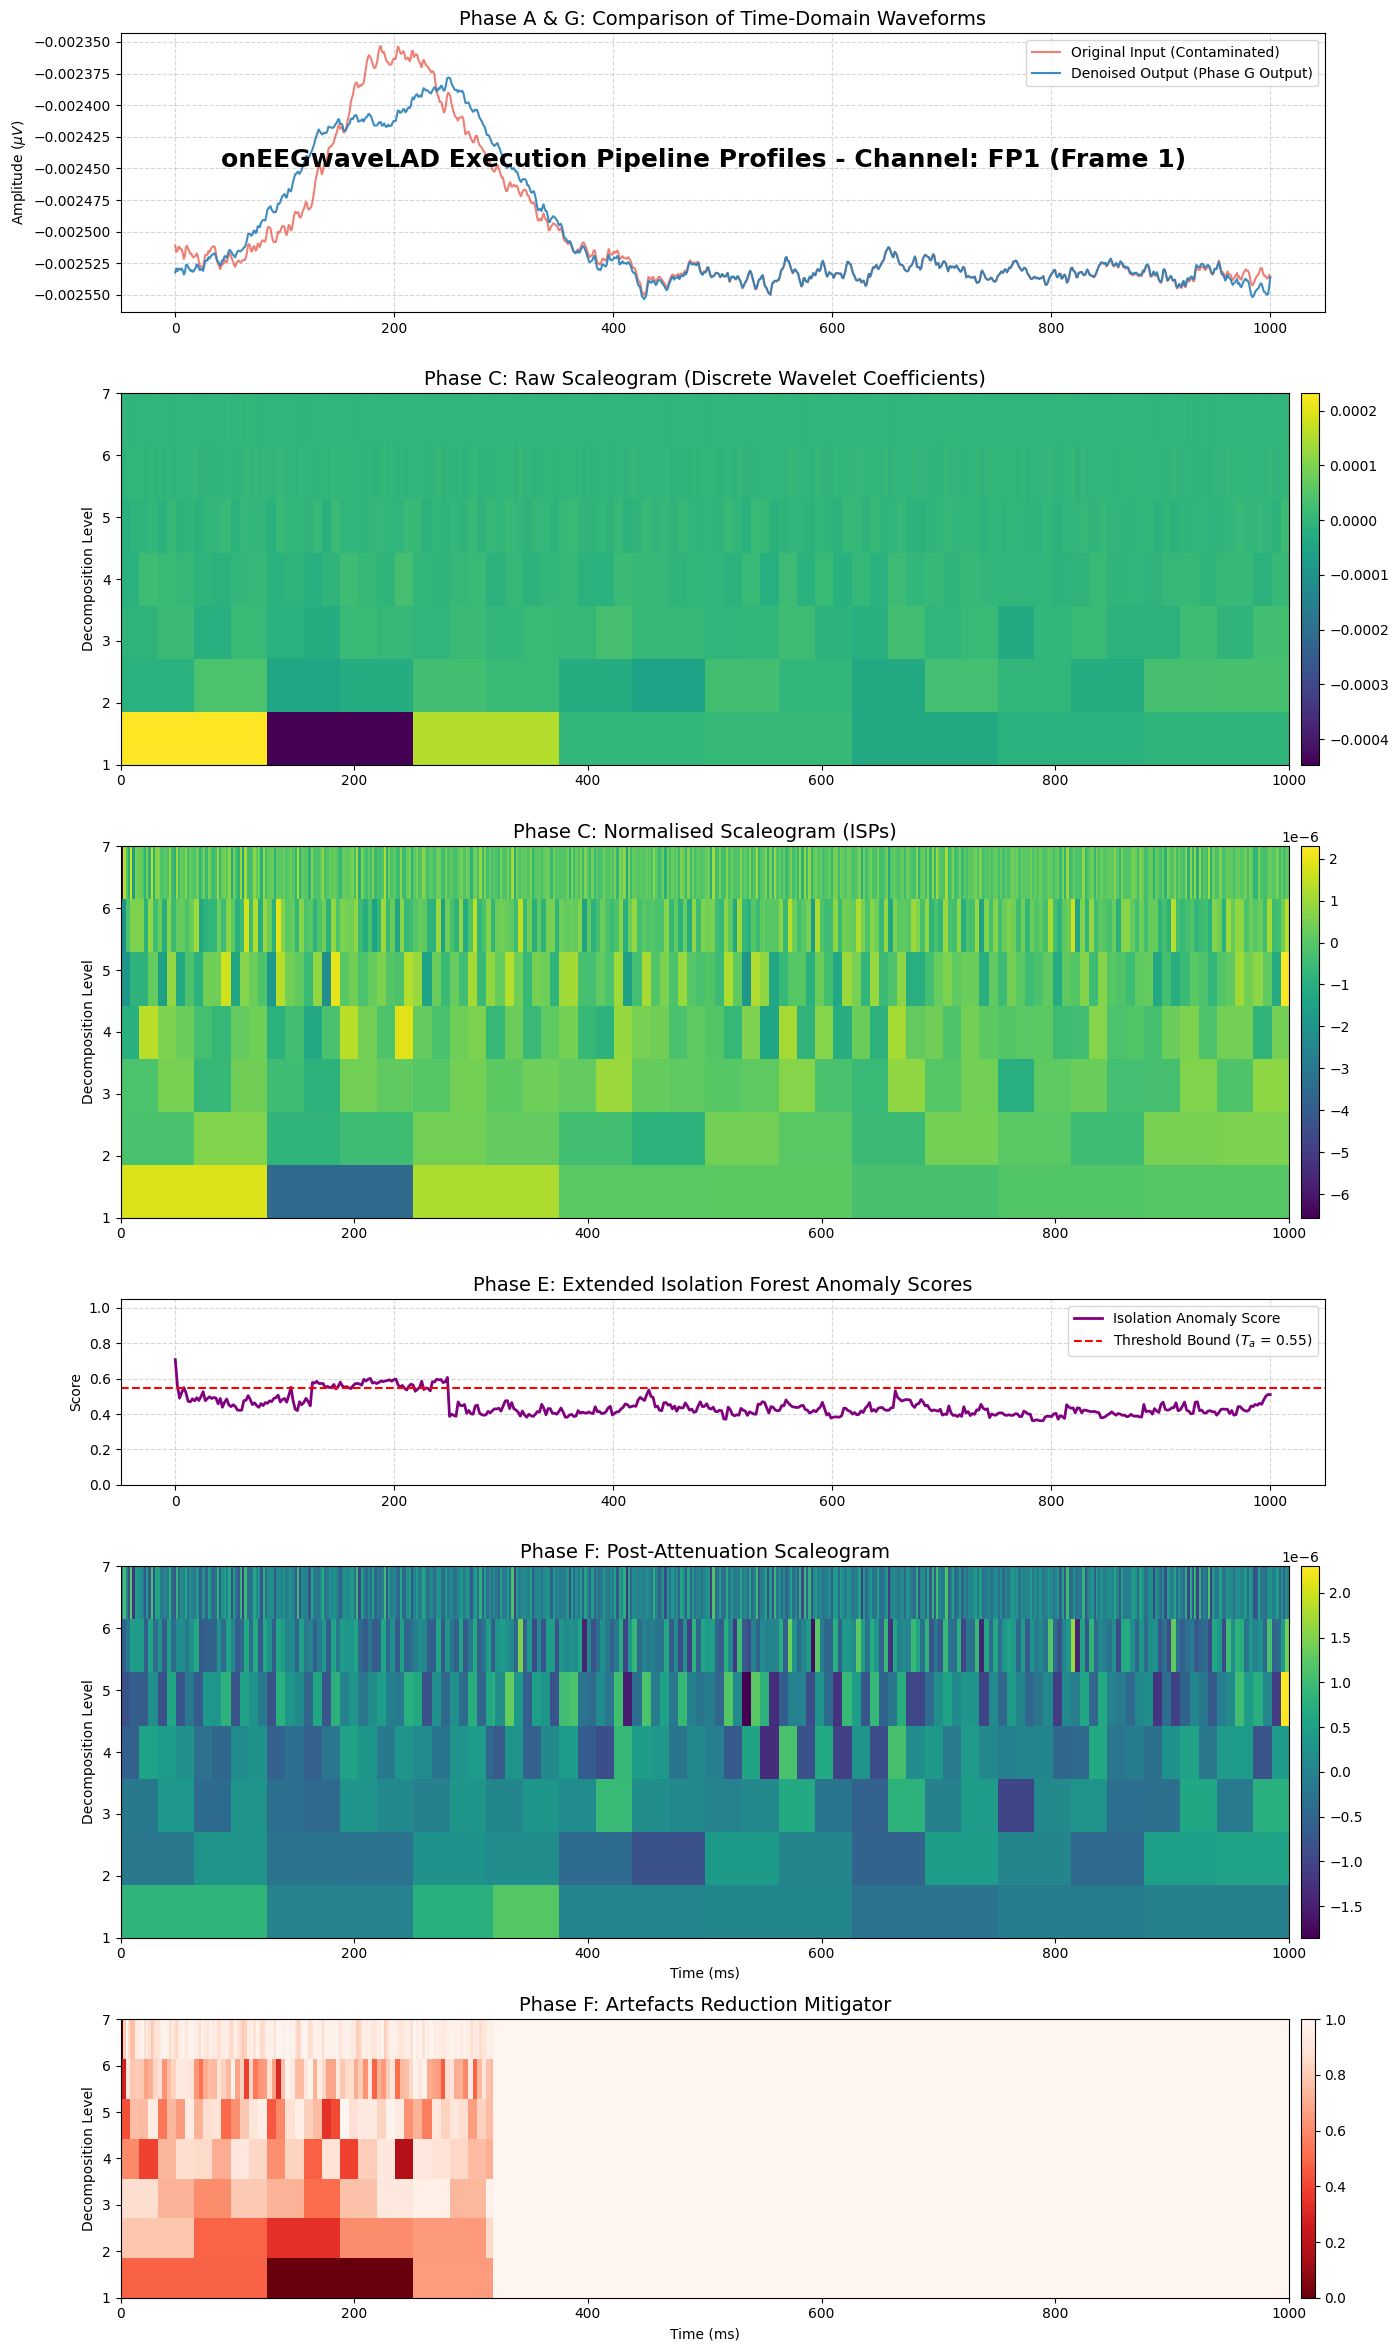

In [8]:
# =================================================================
# Visualization 1: Statistical Visualization and Diagnostics (Static Plot)
# =================================================================
if target_debug_info is not None:
    fig, axes = plt.subplots(6, 1, figsize=(14, 24), gridspec_kw={'height_ratios': [1.5, 2, 2, 1, 2, 1.5]})
    fig.suptitle(f"onEEGwaveLAD Execution Pipeline Profiles - Channel: {raw_data.ch_names[debug_ch_idx]} (Frame {target_window_idx})", fontsize=18, fontweight='bold', y=0.92)

    time_axis = np.linspace(0, windowing.actual_RTWL, len(target_original_sig))
    isp_time_axis = np.linspace(0, windowing.actual_RTWL, len(target_debug_info['Step_E_Scores']))

    # Plot 1: Comparison of Time-Domain Waveforms
    axes[0].plot(time_axis, target_original_sig, label="Original Input (Contaminated)", color='#e74c3c', alpha=0.7, linewidth=1.5)
    axes[0].plot(time_axis, target_denoised_sig, label="Denoised Output (Phase G Output)", color='#2980b9', alpha=0.9, linewidth=1.5)
    axes[0].set_title("Phase A & G: Comparison of Time-Domain Waveforms", fontsize=14)
    axes[0].set_ylabel(r"Amplitude ($\mu V$)")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Raw Discrete Wavelet Coefficients
    sc_raw = target_debug_info['Step_C_Scaleogram_Raw'].T
    im1 = axes[1].imshow(sc_raw, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_raw.shape[0]], interpolation='none')
    axes[1].set_title("Phase C: Raw Scaleogram (Discrete Wavelet Coefficients)", fontsize=14)
    axes[1].set_ylabel("Decomposition Level")
    fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.01)

    # Plot 3: Normalized Scaleogram (ISPs)
    sc_before = target_debug_info['Step_C_Scaleogram_Before'].T
    im2 = axes[2].imshow(sc_before, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_before.shape[0]], interpolation='none')
    axes[2].set_title("Phase C: Normalised Scaleogram (ISPs)", fontsize=14)
    axes[2].set_ylabel("Decomposition Level")
    fig.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.01)

    # Plot 4: Extended Isolation Forest Anomaly Scores
    axes[3].plot(isp_time_axis, target_debug_info['Step_E_Scores'], color='purple', linewidth=2, label='Isolation Anomaly Score')
    axes[3].axhline(y=denoiser.Ta, color='red', linestyle='--', label=f'Threshold Bound ($T_a$ = {denoiser.Ta})')
    axes[3].set_title("Phase E: Extended Isolation Forest Anomaly Scores", fontsize=14)
    axes[3].set_ylabel("Score")
    axes[3].set_ylim(0, 1.05)
    axes[3].legend(loc='upper right')
    axes[3].grid(True, linestyle='--', alpha=0.5)

    # Plot 5: Post-Attenuation Scaleogram
    sc_after = target_debug_info['Step_C_Scaleogram_After'].T
    im4 = axes[4].imshow(sc_after, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_after.shape[0]], interpolation='none')
    axes[4].set_title("Phase F: Post-Attenuation Scaleogram", fontsize=14)
    axes[4].set_ylabel("Decomposition Level")
    axes[4].set_xlabel("Time (ms)")
    fig.colorbar(im4, ax=axes[4], fraction=0.02, pad=0.01)

    # Plot 6: Artifacts Reduction Mitigator Array
    mitigator = target_debug_info['Step_F_Mitigator'].T
    im5 = axes[5].imshow(mitigator, aspect='auto', cmap='Reds_r', origin='lower', vmin=0, vmax=1, extent=[0, windowing.actual_RTWL, 1, mitigator.shape[0]], interpolation='none')
    axes[5].set_title("Phase F: Artefacts Reduction Mitigator", fontsize=14)
    axes[5].set_ylabel("Decomposition Level")
    axes[5].set_xlabel("Time (ms)")
    fig.colorbar(im5, ax=axes[5], fraction=0.02, pad=0.01)

    plt.tight_layout()
    plt.show()


Generating GIF from 60 captured buffer frames... Please wait.
GIF successfully saved as: moving_buffer_evolution.gif


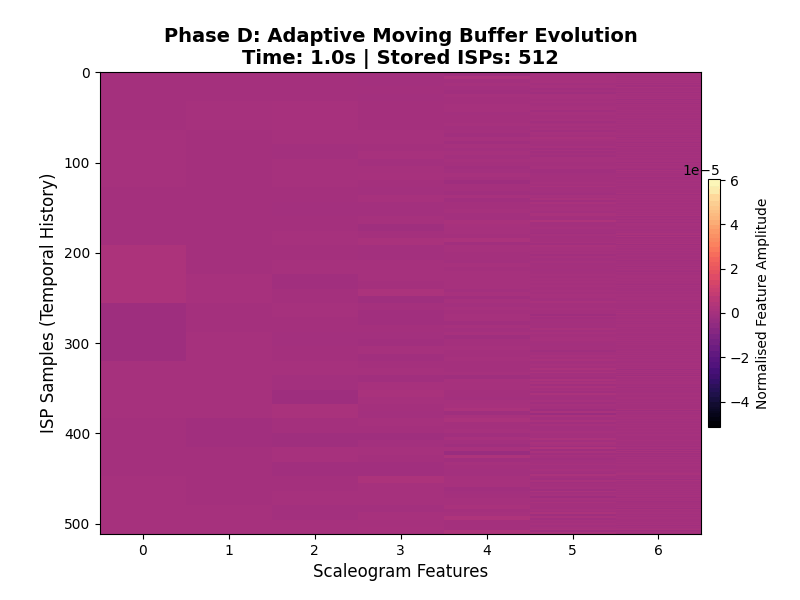

In [9]:
# =================================================================
# Visualization 2: GIF Generation - Continuous Moving Buffer Evolution
# =================================================================
if len(moving_buffer_snapshots) > 0:
    print(f"\nGenerating GIF from {len(moving_buffer_snapshots)} captured buffer frames... Please wait.")

    fig_gif, ax_gif = plt.subplots(figsize=(8, 6))

    # Lock the global color scale bounds to prevent flickering during animation playback
    global_min = np.min([np.min(b) for b in moving_buffer_snapshots])
    global_max = np.max([np.max(b) for b in moving_buffer_snapshots])

    # Initialize the first frame, strictly applying no interpolation to preserve data integrity
    first_buffer = moving_buffer_snapshots[0]
    im_gif = ax_gif.imshow(first_buffer, aspect='auto', cmap='magma',
                           interpolation='none', vmin=global_min, vmax=global_max)

    ax_gif.set_ylabel("ISP Samples (Temporal History)", fontsize=12)
    ax_gif.set_xlabel("Scaleogram Features", fontsize=12)
    cbar = fig_gif.colorbar(im_gif, ax=ax_gif, fraction=0.02, pad=0.01)
    cbar.set_label("Normalised Feature Amplitude")

    title_text = ax_gif.set_title("", fontsize=14, fontweight='bold')

    def update_frame(frame_idx):
        buf_data = moving_buffer_snapshots[frame_idx]
        t = moving_buffer_times[frame_idx]
        im_gif.set_data(buf_data)
        title_text.set_text(f"Phase D: Adaptive Moving Buffer Evolution\nTime: {t:.1f}s | Stored ISPs: {buf_data.shape[0]}")
        return [im_gif, title_text]

    # Set the playback rate to 5 frames per second (fps)
    ani = animation.FuncAnimation(fig_gif, update_frame, frames=len(moving_buffer_snapshots), blit=True)

    gif_filename = "moving_buffer_evolution.gif"
    ani.save(gif_filename, writer='pillow', fps=5)
    plt.close(fig_gif) # Close the static figure to prevent redundant inline rendering

    print(f"GIF successfully saved as: {gif_filename}")

    # Display the rendered animation directly within the Notebook environment
    with open(gif_filename, "rb") as file:
        display(Image(file.read()))
else:
    print("Not enough frames captured to generate a GIF.")

In [10]:
# =================================================================
# Visualization 3: Interactive 3D PCA Scatter Plot (The "Cube")
# =================================================================
import plotly.graph_objects as go
from sklearn.decomposition import PCA

if target_debug_info is not None:
    print("Generating Interactive 3D PCA Cube... (Use your mouse to rotate/zoom)")

    # Extracting Buffer Data and Re-predicting Scores
    buffer_data = target_debug_info['Step_D_Moving_Buffer']
    model = denoiser.models[debug_ch_idx]

    buffer_scores = model.predict(buffer_data)
    is_outlier = buffer_scores > denoiser.Ta

    # PCA dimensionality reduction to 3 dimensions
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(buffer_data)

    inliers_pca = pca_result[~is_outlier]
    outliers_pca = pca_result[is_outlier]

    # Build interactive 3D charts using Plotly
    fig3d = go.Figure()

    # Draw normal Inliers (green dots)
    if len(inliers_pca) > 0:
        fig3d.add_trace(go.Scatter3d(
            x=inliers_pca[:, 0], y=inliers_pca[:, 1], z=inliers_pca[:, 2],
            mode='markers',
            marker=dict(
                size=4,
                color='#2ecc71',
                opacity=0.5
            ),
            name=f'Inliers (Scores <= {denoiser.Ta})'
        ))

    # Draw the outliers that indicate anomalies (red dots)
    if len(outliers_pca) > 0:
        fig3d.add_trace(go.Scatter3d(
            x=outliers_pca[:, 0], y=outliers_pca[:, 1], z=outliers_pca[:, 2],
            mode='markers',
            marker=dict(
                size=6,
                color='#e74c3c',
                opacity=0.9,
                line=dict(width=1, color='black')
            ),
            name=f'Outliers (Scores > {denoiser.Ta})'
        ))

    # Configure interactive layout and axis labels
    fig3d.update_layout(
        title=dict(
            text="Interactive 3D PCA Projection of Adaptive Moving Buffer (ISPs)",
            font=dict(size=18, color='black'),
            x=0.5,
            y=0.95
        ),
        scene=dict(
            xaxis_title=f"PC 1 ({pca.explained_variance_ratio_[0]:.1%} var)",
            yaxis_title=f"PC 2 ({pca.explained_variance_ratio_[1]:.1%} var)",
            zaxis_title=f"PC 3 ({pca.explained_variance_ratio_[2]:.1%} var)",
            xaxis=dict(backgroundcolor="white", gridcolor="lightgrey"),
            yaxis=dict(backgroundcolor="white", gridcolor="lightgrey"),
            zaxis=dict(backgroundcolor="white", gridcolor="lightgrey"),
        ),
        legend=dict(
            yanchor="top",
            y=0.9,
            xanchor="left",
            x=0.05
        ),
        margin=dict(l=0, r=0, b=0, t=0),
        width=900,
        height=700
    )

    # Display interactive charts directly in Notebook
    fig3d.show()
else:
    print("Cannot generate PCA plot: No target buffer data was captured.")

Generating Interactive 3D PCA Cube... (Use your mouse to rotate/zoom)



Generating Global Anomaly Score Trend...


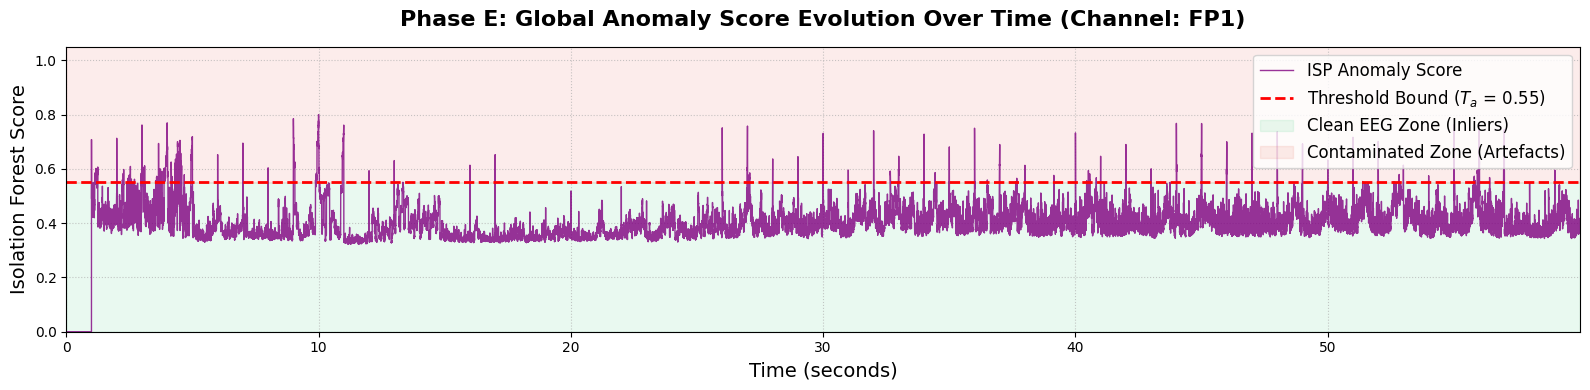

In [11]:
# =================================================================
# Visualization 4: Global Anomaly Score Trend (Phase E over the entire signal)
# =================================================================
if len(global_isp_scores) > 0:
    print("\nGenerating Global Anomaly Score Trend...")

    # Create a wide-format figure for extended timeline visualization
    fig_global, ax_global = plt.subplots(figsize=(16, 4))

    # Plot the global anomaly score trajectory
    ax_global.plot(global_isp_times, global_isp_scores, color='purple', linewidth=1, alpha=0.8, label='ISP Anomaly Score')

    # Plot the anomaly decision threshold Ta
    ax_global.axhline(y=denoiser.Ta, color='red', linestyle='--', linewidth=2, label=f'Threshold Bound ($T_a$ = {denoiser.Ta})')

    # Highlight: Apply shaded regions to intuitively distinguish between the clean (green) and contaminated (red) signal zones
    ax_global.fill_between(global_isp_times, 0, denoiser.Ta, color='#2ecc71', alpha=0.1, label='Clean EEG Zone (Inliers)')
    ax_global.fill_between(global_isp_times, denoiser.Ta, 1.05, color='#e74c3c', alpha=0.1, label='Contaminated Zone (Artefacts)')

    # Configure the plot aesthetics
    ax_global.set_title(f"Phase E: Global Anomaly Score Evolution Over Time (Channel: {raw_data.ch_names[debug_ch_idx]})", fontsize=16, fontweight='bold', pad=15)
    ax_global.set_xlabel("Time (seconds)", fontsize=14)
    ax_global.set_ylabel("Isolation Forest Score", fontsize=14)
    ax_global.set_ylim(0, 1.05)
    ax_global.set_xlim(0, max(global_isp_times))

    # Add legend and grid lines
    ax_global.legend(loc='upper right', fontsize=12)
    ax_global.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No global scores were recorded.")


Generating Distribution Comparison (Clean vs. Contaminated)...


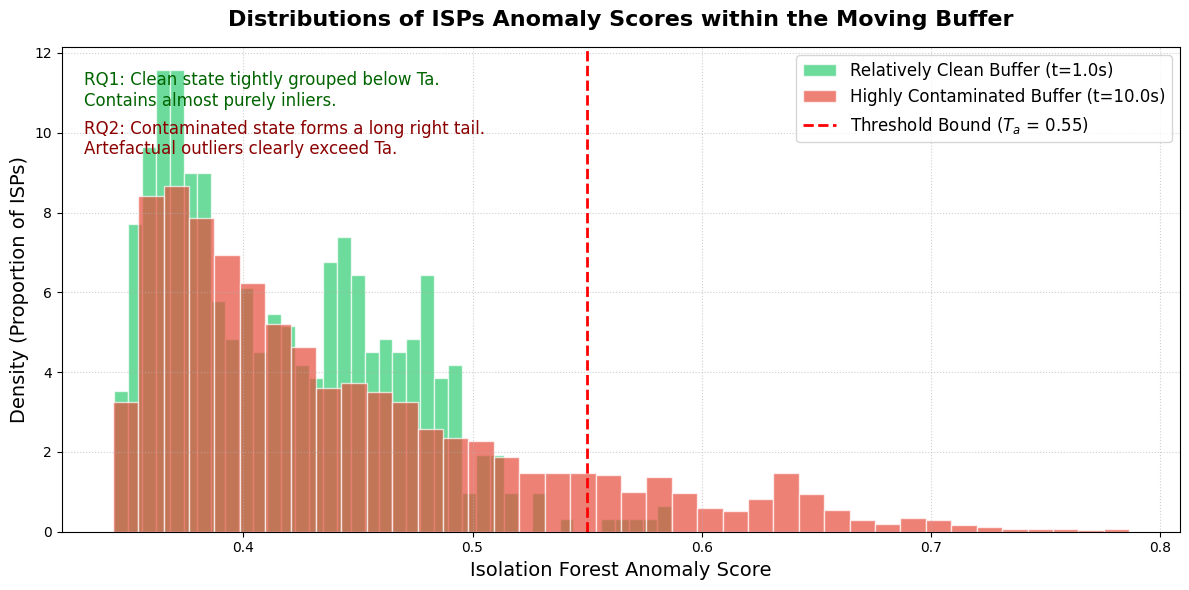

In [12]:
# =================================================================
# Visualization 5: Clean vs. Contaminated Buffer Distributions
# =================================================================
if len(moving_buffer_snapshots) > 0 and target_debug_info is not None:
    print("\nGenerating Distribution Comparison (Clean vs. Contaminated)...")

    # Retrieve the corresponding Isolation Forest model
    model = denoiser.models[debug_ch_idx]

    # 1. Iterate over all captured buffer snapshots and calculate the anomaly scores for all ISPs within each buffer
    snapshot_scores = []
    for buf in moving_buffer_snapshots:
        scores = model.predict(buf)
        snapshot_scores.append(scores)

    # 2. Automatically identify the indices of the buffers representing the two extreme states
    # Cleanest state: The moment when the maximum anomaly score within the buffer is at its minimum
    cleanest_idx = np.argmin([np.max(scores) for scores in snapshot_scores])
    # Most contaminated state: The moment when the maximum anomaly score within the buffer reaches its peak
    contaminated_idx = np.argmax([np.max(scores) for scores in snapshot_scores])

    clean_scores = snapshot_scores[cleanest_idx]
    contam_scores = snapshot_scores[contaminated_idx]
    t_clean = moving_buffer_times[cleanest_idx]
    t_contam = moving_buffer_times[contaminated_idx]

    # 3. Plot overlapping histograms to compare the distributions
    fig_dist, ax_dist = plt.subplots(figsize=(12, 6))

    # Plot the distribution of the clean state (green)
    ax_dist.hist(clean_scores, bins=40, color='#2ecc71', alpha=0.7,
                 label=f'Relatively Clean Buffer (t={t_clean:.1f}s)', density=True, edgecolor='white')

    # Plot the distribution of the contaminated state (red)
    ax_dist.hist(contam_scores, bins=40, color='#e74c3c', alpha=0.7,
                 label=f'Highly Contaminated Buffer (t={t_contam:.1f}s)', density=True, edgecolor='white')

    # Plot the anomaly decision threshold Ta
    ax_dist.axvline(x=denoiser.Ta, color='red', linestyle='--', linewidth=2, label=f'Threshold Bound ($T_a$ = {denoiser.Ta})')

    # Configure the title and axis labels
    ax_dist.set_title("Distributions of ISPs Anomaly Scores within the Moving Buffer", fontsize=16, fontweight='bold', pad=15)
    ax_dist.set_xlabel("Isolation Forest Anomaly Score", fontsize=14)
    ax_dist.set_ylabel("Density (Proportion of ISPs)", fontsize=14)

    # Embed academic conclusion annotations directly into the plot
    ax_dist.text(0.02, 0.95, f"RQ1: Clean state tightly grouped below Ta.\nContains almost purely inliers.",
                 transform=ax_dist.transAxes, fontsize=12, color='darkgreen', verticalalignment='top')
    ax_dist.text(0.02, 0.85, f"RQ2: Contaminated state forms a long right tail.\nArtefactual outliers clearly exceed Ta.",
                 transform=ax_dist.transAxes, fontsize=12, color='darkred', verticalalignment='top')

    ax_dist.legend(loc='upper right', fontsize=12)
    ax_dist.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to generate the distribution comparison. Ensure the simulation ran long enough.")

In [13]:
!pip install scikit-posthocs
!pip install statsmodels

In [14]:
# ==============================================================================
# CELL 1: Imports & Dual-Mode Quality Metrics Evaluator
# ==============================================================================
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import pearsonr, friedmanchisquare, wilcoxon
from scipy.signal import welch, coherence
from sklearn.metrics import mutual_info_score
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

class OnEEGWaveLAD_MetricsEvaluator:
    def __init__(self, fs=1024.0):
        self.fs = fs
        self.bands = {
            'Delta': (0.5, 4), 'Theta': (4, 8),
            'Alpha': (8, 13), 'Beta':  (13, 30), 'Gamma': (30, 50)
        }

    def calc_snr_psnr_diff(self, orig, denoised, noisy=None):
        if noisy is not None and not np.array_equal(orig, noisy):
            mse_noisy = np.mean((orig - noisy)**2)
            mse_denoised = np.mean((orig - denoised)**2)
            var_orig = np.var(orig)

            snr_noisy = 10 * np.log10(var_orig / mse_noisy) if mse_noisy > 1e-10 else 0.0
            snr_denoised = 10 * np.log10(var_orig / mse_denoised) if mse_denoised > 1e-10 else 0.0
            snr_diff = snr_denoised - snr_noisy

            max_val = np.max(np.abs(orig))
            psnr_noisy = 10 * np.log10((max_val**2) / mse_noisy) if mse_noisy > 1e-10 else 0.0
            psnr_denoised = 10 * np.log10((max_val**2) / mse_denoised) if mse_denoised > 1e-10 else 0.0
            psnr_diff = psnr_denoised - psnr_noisy
        else:
            noise_removed = orig - denoised
            var_orig = np.var(orig)
            var_denoised = np.var(denoised)
            var_noise = np.var(noise_removed)

            snr_denoised = 10 * np.log10(var_denoised / var_noise) if var_noise > 1e-10 else 0.0
            snr_orig = 10 * np.log10(var_denoised / var_orig) if var_orig > 1e-10 else 0.0
            snr_diff = snr_denoised - snr_orig

            max_val = np.max(np.abs(orig))
            mse_denoised = np.mean(noise_removed**2)
            psnr_denoised = 10 * np.log10((max_val**2) / mse_denoised) if mse_denoised > 1e-10 else 0.0
            psnr_orig = 10 * np.log10((max_val**2) / var_orig) if var_orig > 1e-10 else 0.0
            psnr_diff = psnr_denoised - psnr_orig

        return snr_diff, psnr_diff

    def calc_rmse(self, orig, denoised):
        return np.sqrt(np.mean((orig - denoised)**2))

    def calc_correlation(self, orig, denoised):
        if np.std(orig) < 1e-10 or np.std(denoised) < 1e-10:
            return 0.0
        corr, _ = pearsonr(orig, denoised)
        return corr

    def calc_mutual_information(self, orig, denoised, bins=50):
        c_xy, _, _ = np.histogram2d(orig, denoised, bins=bins)
        return mutual_info_score(None, None, contingency=c_xy)

    def calc_spectral_metrics(self, orig, denoised):
        f_orig, psd_orig = welch(orig, fs=self.fs, nperseg=int(self.fs))
        f_den, psd_den = welch(denoised, fs=self.fs, nperseg=int(self.fs))
        f_coh, coh = coherence(orig, denoised, fs=self.fs, nperseg=int(self.fs))

        bppe, msc = {}, {}
        for band, (fmin, fmax) in self.bands.items():
            idx_psd = np.logical_and(f_orig >= fmin, f_orig <= fmax)
            idx_coh = np.logical_and(f_coh >= fmin, f_coh <= fmax)
            power_orig = np.trapz(psd_orig[idx_psd], f_orig[idx_psd])
            power_den = np.trapz(psd_den[idx_psd], f_den[idx_psd])

            bppe[band] = np.abs(power_orig - power_den) / power_orig if power_orig > 0 else 0.0
            msc[band] = np.mean(coh[idx_coh]) if np.sum(idx_coh) > 0 else 0.0

        return bppe, msc

    def evaluate_channel(self, orig_signal, denoised_signal, noisy_signal=None):
        orig = np.asarray(orig_signal).flatten()
        denoised = np.asarray(denoised_signal).flatten()
        noisy = np.asarray(noisy_signal).flatten() if noisy_signal is not None else None

        snr_diff, psnr_diff = self.calc_snr_psnr_diff(orig, denoised, noisy)
        rmse = self.calc_rmse(orig, denoised)
        corr = self.calc_correlation(orig, denoised)
        mi = self.calc_mutual_information(orig, denoised)
        bppe, msc = self.calc_spectral_metrics(orig, denoised)

        results = {"SNR-Diff": snr_diff, "PSNR-Diff": psnr_diff, "RMSE": rmse, "Corr": corr, "MI": mi}
        for band in self.bands.keys():
            results[f"BPPE_{band}"] = bppe[band]
            results[f"MSC_{band}"] = msc[band]

        return results

In [15]:
# ==============================================================================
# CELL 2: Batch Execution & Stream Processing Loop
# ==============================================================================

# --- Global Configs ---
datasetName = "N170"
rootPath = "/content/drive/MyDrive/"
montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
parametersOfDenoiser = None

TEST_MODE = True # Set to False when you want to run all subjects and all data
test_subject_ids = [str(i) for i in range(1, 11)] if TEST_MODE else [str(i) for i in range(1, 31)]
bs_list = [1, 5, 10, 15, 20, 30, 35] if TEST_MODE else [1, 5, 10, 15, 20, 25, 30, 35, 40]
max_windows = 25 if TEST_MODE else None

def evaluate_single_subject(subject_id, bs_list, max_windows=None):
    print(f"\n{'='*50}\n🚀 Processing Subject: sub-{subject_id}\n{'='*50}")

    # Load dataset
    raw_data = loadDataset(
        name=datasetName, subject=subject_id, montageName=montageName,
        usedChannels=usedChannels, rootPath=rootPath,
        montageChannelNames=montageChannelNames, parametersOfDenoiser=parametersOfDenoiser, verbose=False
    )

    target_channels = raw_data.ch_names[:3] if TEST_MODE else raw_data.ch_names
    channel_indices = [raw_data.ch_names.index(ch) for ch in target_channels if ch in raw_data.ch_names]
    target_channels = [raw_data.ch_names[idx] for idx in channel_indices]
    num_channels = len(raw_data.ch_names)

    windowing = OnEEGWaveLAD_Windowing(raw_data, RTWL=1000)
    dwt = OnEEGWaveLAD_DWT(MW='sym4')
    evaluator = OnEEGWaveLAD_MetricsEvaluator(fs=raw_data.info['sfreq'])

    denoisers = {bs: OnEEGWaveLAD_Denoiser(n_channels=num_channels, Bs=bs, IFS=512, Ta=0.55, Es=35) for bs in bs_list}
    denoised_signals_dict = {bs: [] for bs in bs_list}
    original_signals_list, noisy_signals_list = [], []

    # Stream processing
    for i, win in enumerate(tqdm(windowing.get_window_stream(), desc=f"Streaming sub-{subject_id}")):
        if max_windows is not None and i >= max_windows: break

        orig_win = win['original_window']
        noisy_win = win['dwt_input']
        original_signals_list.append(orig_win)
        noisy_signals_list.append(noisy_win)

        coeffs = dwt.decompose_window(noisy_win)
        for bs in bs_list:
            denoised_sigs = denoisers[bs].process_window(all_channels_coeffs=coeffs, target_len=orig_win.shape[1], return_debug=False)
            denoised_signals_dict[bs].append(denoised_sigs)

    # Reconstruct and Evaluate
    full_original = np.concatenate(original_signals_list, axis=1)
    full_noisy = np.concatenate(noisy_signals_list, axis=1)

    sub_results = []
    for ch_name, ch_idx in tqdm(zip(target_channels, channel_indices), total=len(target_channels), desc="Evaluating Channels"):
        orig_ch = full_original[ch_idx]
        noisy_ch = full_noisy[ch_idx]

        for bs in bs_list:
            denoised_ch = np.concatenate(denoised_signals_dict[bs], axis=1)[ch_idx]
            metrics = evaluator.evaluate_channel(orig_ch, denoised_ch, noisy_ch)
            row = {"Subject": f"sub-{subject_id}", "Channel": ch_name, "Bs": bs}
            row.update(metrics)
            sub_results.append(row)

    return sub_results

# Execute Batch
all_results = []
for subj in test_subject_ids:
    all_results.extend(evaluate_single_subject(subj, bs_list, max_windows))

df_results = pd.DataFrame(all_results)
csv_filename = "onEEGWaveLAD_Metrics_ALL.csv"
df_results.to_csv(csv_filename, index=False)
print(f"✅ Data processing complete! Saved to {csv_filename}")


🚀 Processing Subject: sub-1
Reading /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.fdt
Reading 0 ... 699391  =      0.000 ...   682.999 secs...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).


Streaming sub-1: 0it [00:00, ?it/s]

Evaluating Channels:   0%|          | 0/3 [00:00<?, ?it/s]


🚀 Processing Subject: sub-2
Reading /content/drive/MyDrive/N170 All Data and Scripts/2/2_N170_shifted.fdt
Reading 0 ... 683007  =      0.000 ...   666.999 secs...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).


Streaming sub-2: 0it [00:00, ?it/s]

...

Evaluating Channels:   0%|          | 0/3 [00:00<?, ?it/s]


🚀 Processing Subject: sub-10
Reading /content/drive/MyDrive/N170 All Data and Scripts/10/10_N170_shifted.fdt
Reading 0 ... 556031  =      0.000 ...   542.999 secs...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).


Streaming sub-10: 0it [00:00, ?it/s]

Evaluating Channels:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Data processing complete! Saved to onEEGWaveLAD_Metrics_ALL.csv



📊 Run Statistical Analysis: Metric-Aggregated / Single-Subject (sub-1)
Matrix Dimension: N=3 observations x k=7 treatments (Buffer Sizes)
Friedman Test: Chi-square = 16.3291, p-value = 1.2092e-02
-> [SUCCESS]: Reject H0 (p < 0.05). Significant differences exist.

--- Pairwise Post-hoc Wilcoxon Sign-Rank Test (Holm-Bonferroni) ---
  [NS] Bs(1) vs Bs(5): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(1) vs Bs(10): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(1) vs Bs(15): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(1) vs Bs(20): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(1) vs Bs(30): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(1) vs Bs(35): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(5) vs Bs(10): Uncorrected p=5.0000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(5) vs Bs(15): Uncorrected p=2.5000e-01 -> Holm-corrected p=1.0000e+00
  [NS] Bs(5) vs Bs(20): Unco

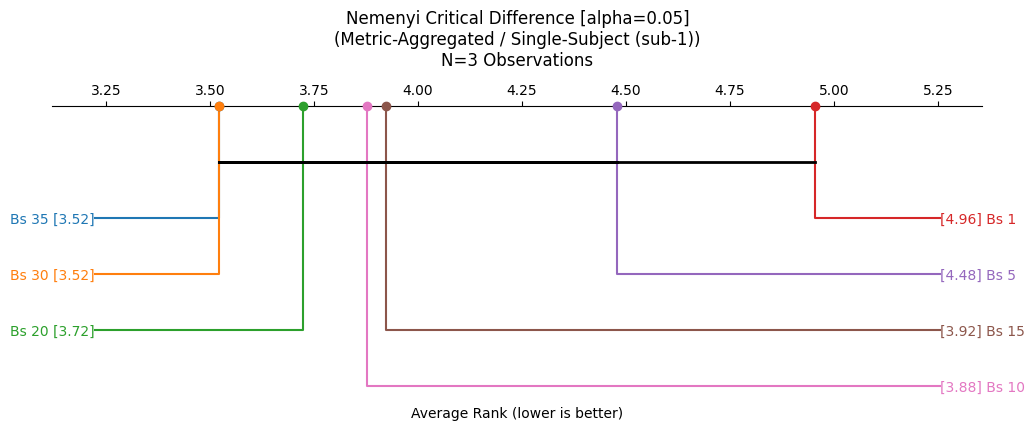


📊 Run Statistical Analysis: Channel-Specific / Multiple-Subjects (N=900)
Matrix Dimension: N=30 observations x k=7 treatments (Buffer Sizes)
Friedman Test: Chi-square = 117.5919, p-value = 5.2202e-23
-> [SUCCESS]: Reject H0 (p < 0.05). Significant differences exist.

--- Pairwise Post-hoc Wilcoxon Sign-Rank Test (Holm-Bonferroni) ---
  [SIG] Bs(1) vs Bs(5): Uncorrected p=1.2861e-05 -> Holm-corrected p=2.0578e-04
  [SIG] Bs(1) vs Bs(10): Uncorrected p=2.5923e-06 -> Holm-corrected p=4.5980e-05
  [SIG] Bs(1) vs Bs(15): Uncorrected p=1.9149e-06 -> Holm-corrected p=4.0214e-05
  [SIG] Bs(1) vs Bs(20): Uncorrected p=2.5545e-06 -> Holm-corrected p=4.5980e-05
  [SIG] Bs(1) vs Bs(30): Uncorrected p=1.9185e-06 -> Holm-corrected p=4.0214e-05
  [SIG] Bs(1) vs Bs(35): Uncorrected p=1.9185e-06 -> Holm-corrected p=4.0214e-05
  [SIG] Bs(5) vs Bs(10): Uncorrected p=4.5028e-03 -> Holm-corrected p=2.2514e-02
  [SIG] Bs(5) vs Bs(15): Uncorrected p=1.1447e-04 -> Holm-corrected p=1.1447e-03
  [SIG] Bs(5) vs

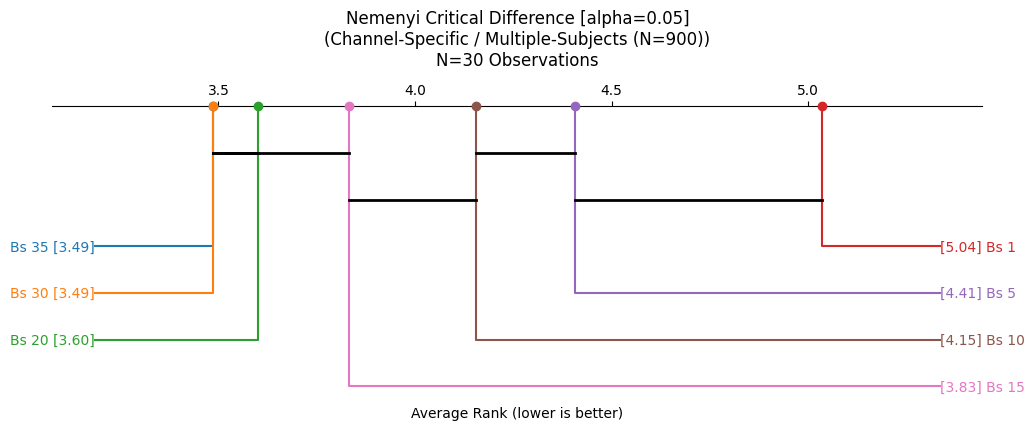


📊 Run Statistical Analysis: Channel-Aggregated / Multiple-Subjects (N=30)
Matrix Dimension: N=10 observations x k=7 treatments (Buffer Sizes)
Friedman Test: Chi-square = 43.7673, p-value = 8.2206e-08
-> [SUCCESS]: Reject H0 (p < 0.05). Significant differences exist.

--- Pairwise Post-hoc Wilcoxon Sign-Rank Test (Holm-Bonferroni) ---
  [SIG] Bs(1) vs Bs(5): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [SIG] Bs(1) vs Bs(10): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [SIG] Bs(1) vs Bs(15): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [SIG] Bs(1) vs Bs(20): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [SIG] Bs(1) vs Bs(30): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [SIG] Bs(1) vs Bs(35): Uncorrected p=1.9531e-03 -> Holm-corrected p=4.1016e-02
  [NS] Bs(5) vs Bs(10): Uncorrected p=2.7344e-02 -> Holm-corrected p=1.6406e-01
  [NS] Bs(5) vs Bs(15): Uncorrected p=5.8594e-03 -> Holm-corrected p=6.4453e-02
  [NS] Bs(5) vs Bs

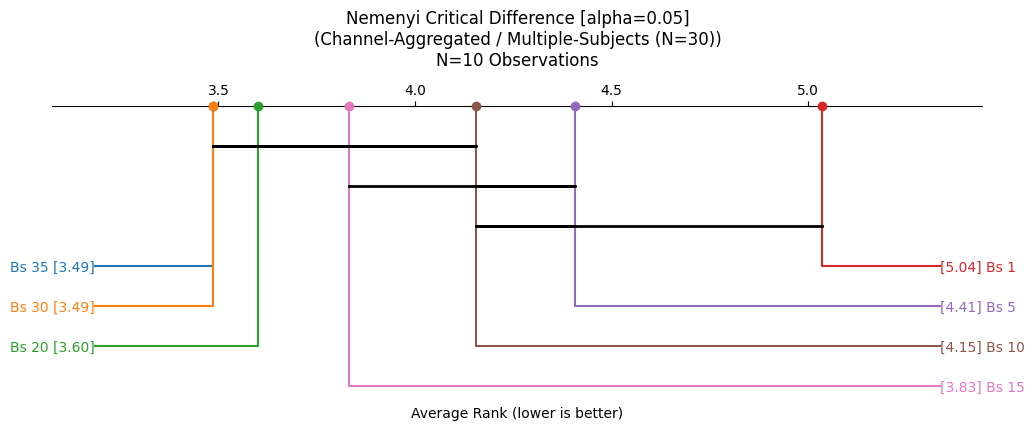

In [16]:
# ==============================================================================
# CELL 3: Robust Statistical Pipeline
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

METRICS_LOWER_BETTER = [
    'PSNR-Diff', 'RMSE',
    'BPPE_Delta', 'BPPE_Theta', 'BPPE_Alpha', 'BPPE_Beta', 'BPPE_Gamma',
    'MSC_Delta', 'MSC_Theta', 'MSC_Gamma'
]

def prepare_ranked_dataframe(df):
    """
    1. Flips polarities so Higher = Better.
    2. Melts the dataframe.
    3. Calculates strict RANKS within each lowest-level block [Subject, Channel, Metric].
    """
    df_stat = df.copy()

    # Flip the sign of lower-better metrics
    for m in METRICS_LOWER_BETTER:
        if m in df_stat.columns:
            df_stat[m] = -df_stat[m]

    # Melt the dataframe
    metric_cols = [c for c in df.columns if c not in ['Subject', 'Channel', 'Bs']]
    df_melt = df_stat.melt(
        id_vars=['Subject', 'Channel', 'Bs'],
        value_vars=metric_cols,
        var_name='Metric',
        value_name='Value'
    )

    # CRITICAL FIX: Compute ranks internally first.
    # Ascending=False means the best method (highest value) gets Rank 1.
    df_melt['Rank'] = df_melt.groupby(['Subject', 'Channel', 'Metric'])['Value'].rank(ascending=False)

    return df_melt

def run_nemenyi_statistical_test(matrix_pivot, title_desc, alpha=0.05):
    """
    Executes Friedman, pairwise Wilcoxon-Holm, and generates Nemenyi CD Diagrams.
    Expects matrix_pivot to have exactly N rows (observations) and k cols (methods).
    """
    k = matrix_pivot.shape[1]
    N = matrix_pivot.shape[0]

    print(f"\n{'='*70}")
    print(f"📊 Run Statistical Analysis: {title_desc}")
    print(f"Matrix Dimension: N={N} observations x k={k} treatments (Buffer Sizes)")
    print(f"{'='*70}")

    if N <= 1:
        print("-> [WARNING]: Too few observations.")
        return

    # 1. Friedman Chi-square Test
    stat, p_val = friedmanchisquare(*[matrix_pivot[col].values for col in matrix_pivot.columns])
    print(f"Friedman Test: Chi-square = {stat:.4f}, p-value = {p_val:.4e}")

    if p_val < alpha:
        print(f"-> [SUCCESS]: Reject H0 (p < {alpha}). Significant differences exist.")

        methods = matrix_pivot.columns
        print("\n--- Pairwise Post-hoc Wilcoxon Sign-Rank Test (Holm-Bonferroni) ---")
        pairs = list(itertools.combinations(methods, 2))
        p_vals_wilcoxon = []

        for m1, m2 in pairs:
            diff = matrix_pivot[m1] - matrix_pivot[m2]
            if np.all(diff == 0):
                p_vals_wilcoxon.append(1.0)
            else:
                _, p_w = wilcoxon(matrix_pivot[m1], matrix_pivot[m2])
                p_vals_wilcoxon.append(p_w)

        reject, pvals_corrected, _, _ = multipletests(p_vals_wilcoxon, alpha=alpha, method='holm')

        for (m1, m2), p_raw, p_corr, rej in zip(pairs, p_vals_wilcoxon, pvals_corrected, reject):
            sig_mark = "[SIG]" if rej else "[NS]"
            print(f"  {sig_mark} Bs({m1}) vs Bs({m2}): Uncorrected p={p_raw:.4e} -> Holm-corrected p={p_corr:.4e}")

        # 3. Nemenyi CD Diagram
        print("\n--- Generating Nemenyi Critical Difference Diagram ---")
        # Ensure matrix is properly formatted for scikit-posthocs
        clean_matrix = matrix_pivot.copy()
        clean_matrix.index = range(len(clean_matrix))

        nemenyi_pvals = sp.posthoc_nemenyi_friedman(clean_matrix)

        # We use the explicit means of our calculated ranks for the plot
        avg_ranks = matrix_pivot.mean()

        plt.figure(figsize=(12, 4))
        sp.critical_difference_diagram(
            ranks=avg_ranks,
            sig_matrix=nemenyi_pvals,
            label_fmt_left='Bs {label} [{rank:.2f}]',
            label_fmt_right='[{rank:.2f}] Bs {label}',
            text_h_margin=0.3
        )
        plt.title(f'Nemenyi Critical Difference [alpha={alpha}]\n({title_desc})\nN={N} Observations', fontsize=12, pad=20)
        plt.xlabel('Average Rank (lower is better)', fontsize=10)
        plt.show()
    else:
        print(f"-> [NS]: Fail to reject H0 (p >= {alpha}). No statistically significant differences.")


# ==============================================================================
# Executing Three Target Scenarios
# ==============================================================================
# Generate the base dataframe containing the actual Ranks
df_ranked = prepare_ranked_dataframe(df_results)

# ------------------------------------------------------------------------------
# Scenario 1: Metric-Aggregated / Single-Subject (N=30)
# "aggregating the ranks of the evaluation metrics for each of the channels"
# ------------------------------------------------------------------------------
sample_subject = df_ranked['Subject'].unique()[0]
df_sub = df_ranked[df_ranked['Subject'] == sample_subject]

# Average the ranks across metrics to get ONE score per channel per method
agg_sub = df_sub.groupby(['Channel', 'Bs'])['Rank'].mean().reset_index()
# Pivot to ensure N = 30 Channels
pivot_sub = agg_sub.pivot(index='Channel', columns='Bs', values='Rank').dropna()

run_nemenyi_statistical_test(
    pivot_sub,
    title_desc=f"Metric-Aggregated / Single-Subject ({sample_subject})"
)

# ------------------------------------------------------------------------------
# Scenario 2: Channel-Specific / Multiple-Subjects (N=900)
# "treats channels individually... N = 30 x 30 = 900"
# ------------------------------------------------------------------------------
# Average the ranks across metrics to get ONE score per (Subject+Channel) per method
agg_chan = df_ranked.groupby(['Subject', 'Channel', 'Bs'])['Rank'].mean().reset_index()
# Pivot to ensure N = Subjects * Channels
pivot_chan = agg_chan.pivot(index=['Subject', 'Channel'], columns='Bs', values='Rank').dropna()

run_nemenyi_statistical_test(
    pivot_chan,
    title_desc="Channel-Specific / Multiple-Subjects (N=900)"
)

# ------------------------------------------------------------------------------
# Scenario 3: Channel-Aggregated / Multiple-Subjects (N=30)
# "average of ranks across channels for each subject... N=30"
# ------------------------------------------------------------------------------
# We take the agg_chan from Scenario 2, and average it further across channels
agg_global = agg_chan.groupby(['Subject', 'Bs'])['Rank'].mean().reset_index()
# Pivot to ensure N = 30 Subjects
pivot_global = agg_global.pivot(index='Subject', columns='Bs', values='Rank').dropna()

run_nemenyi_statistical_test(
    pivot_global,
    title_desc="Channel-Aggregated / Multiple-Subjects (N=30)"
)